# Интерпретация

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

LinearRegression     | StandardScaler : RMSE=2229.76  MAPE=0.0505
LinearRegression     | MinMaxScaler   : RMSE=2229.76  MAPE=0.0505
Lasso                | StandardScaler : RMSE=2226.15  MAPE=0.0504
Lasso                | MinMaxScaler   : RMSE=2226.11  MAPE=0.0504
GradientBoosting     | StandardScaler : RMSE=2474.44  MAPE=0.0576
GradientBoosting     | MinMaxScaler   : RMSE=2469.00  MAPE=0.0576


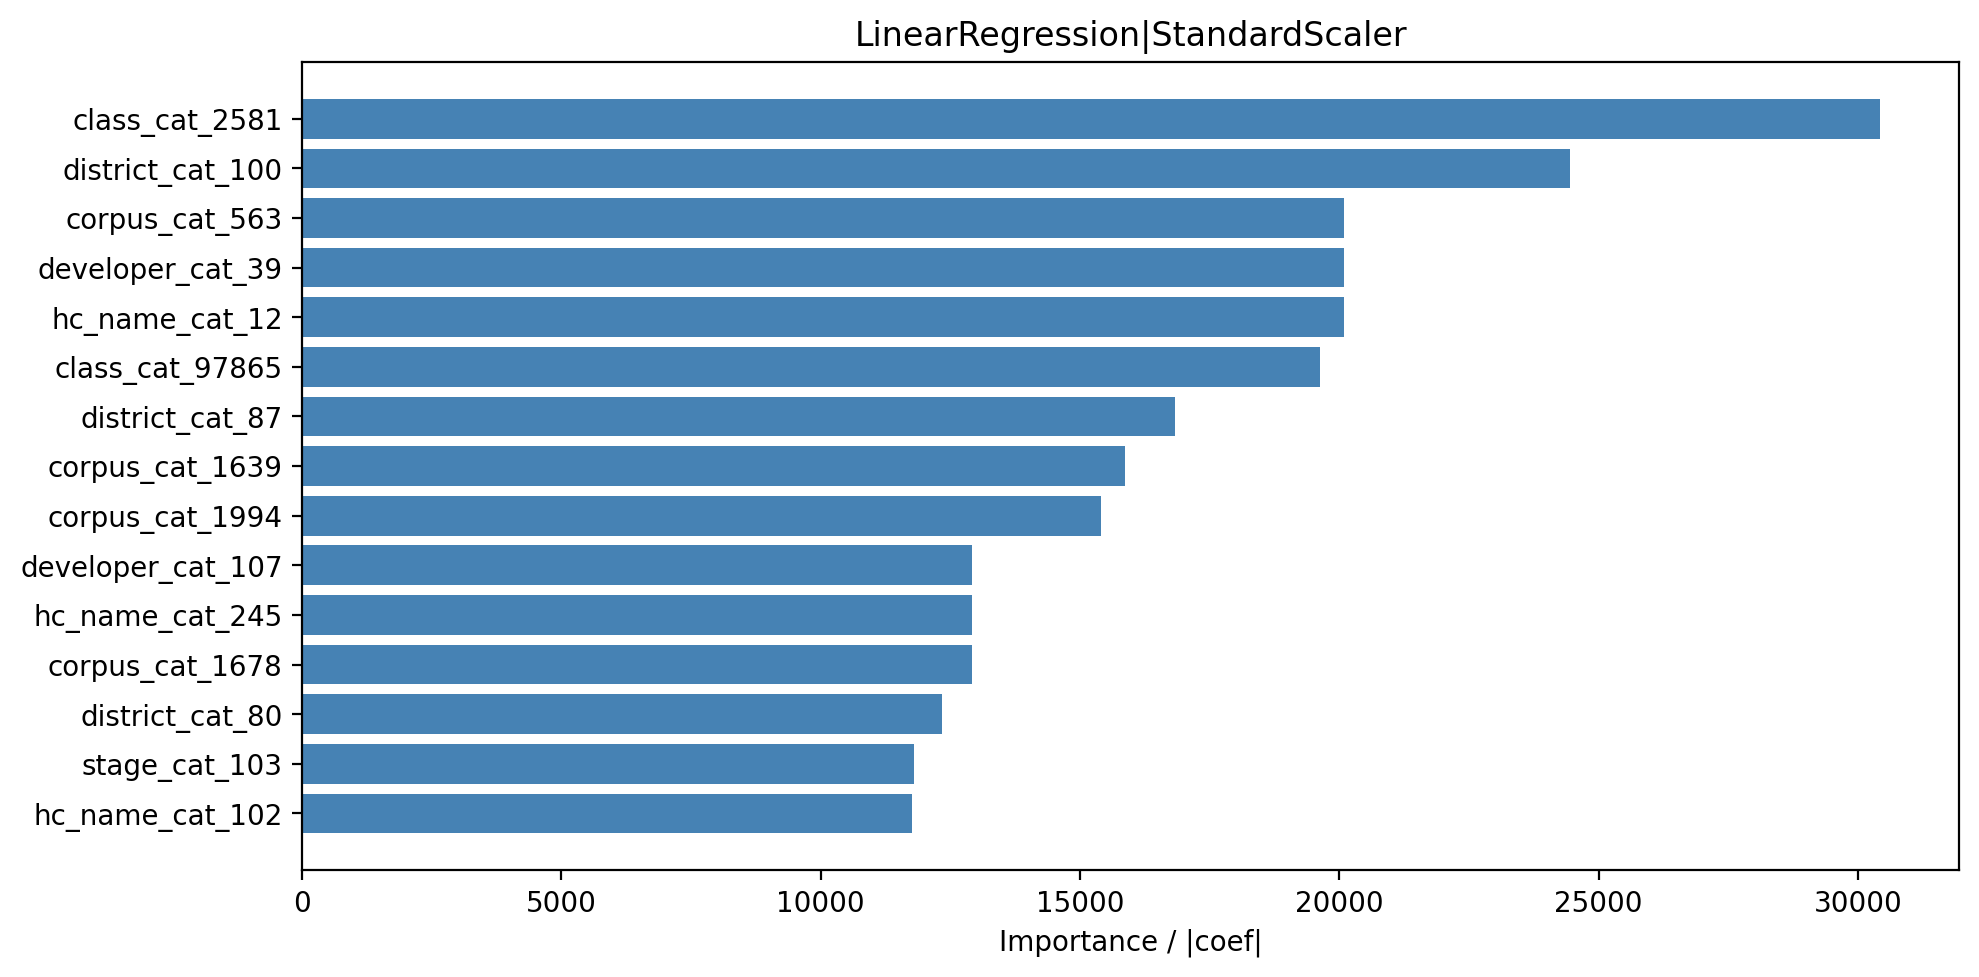

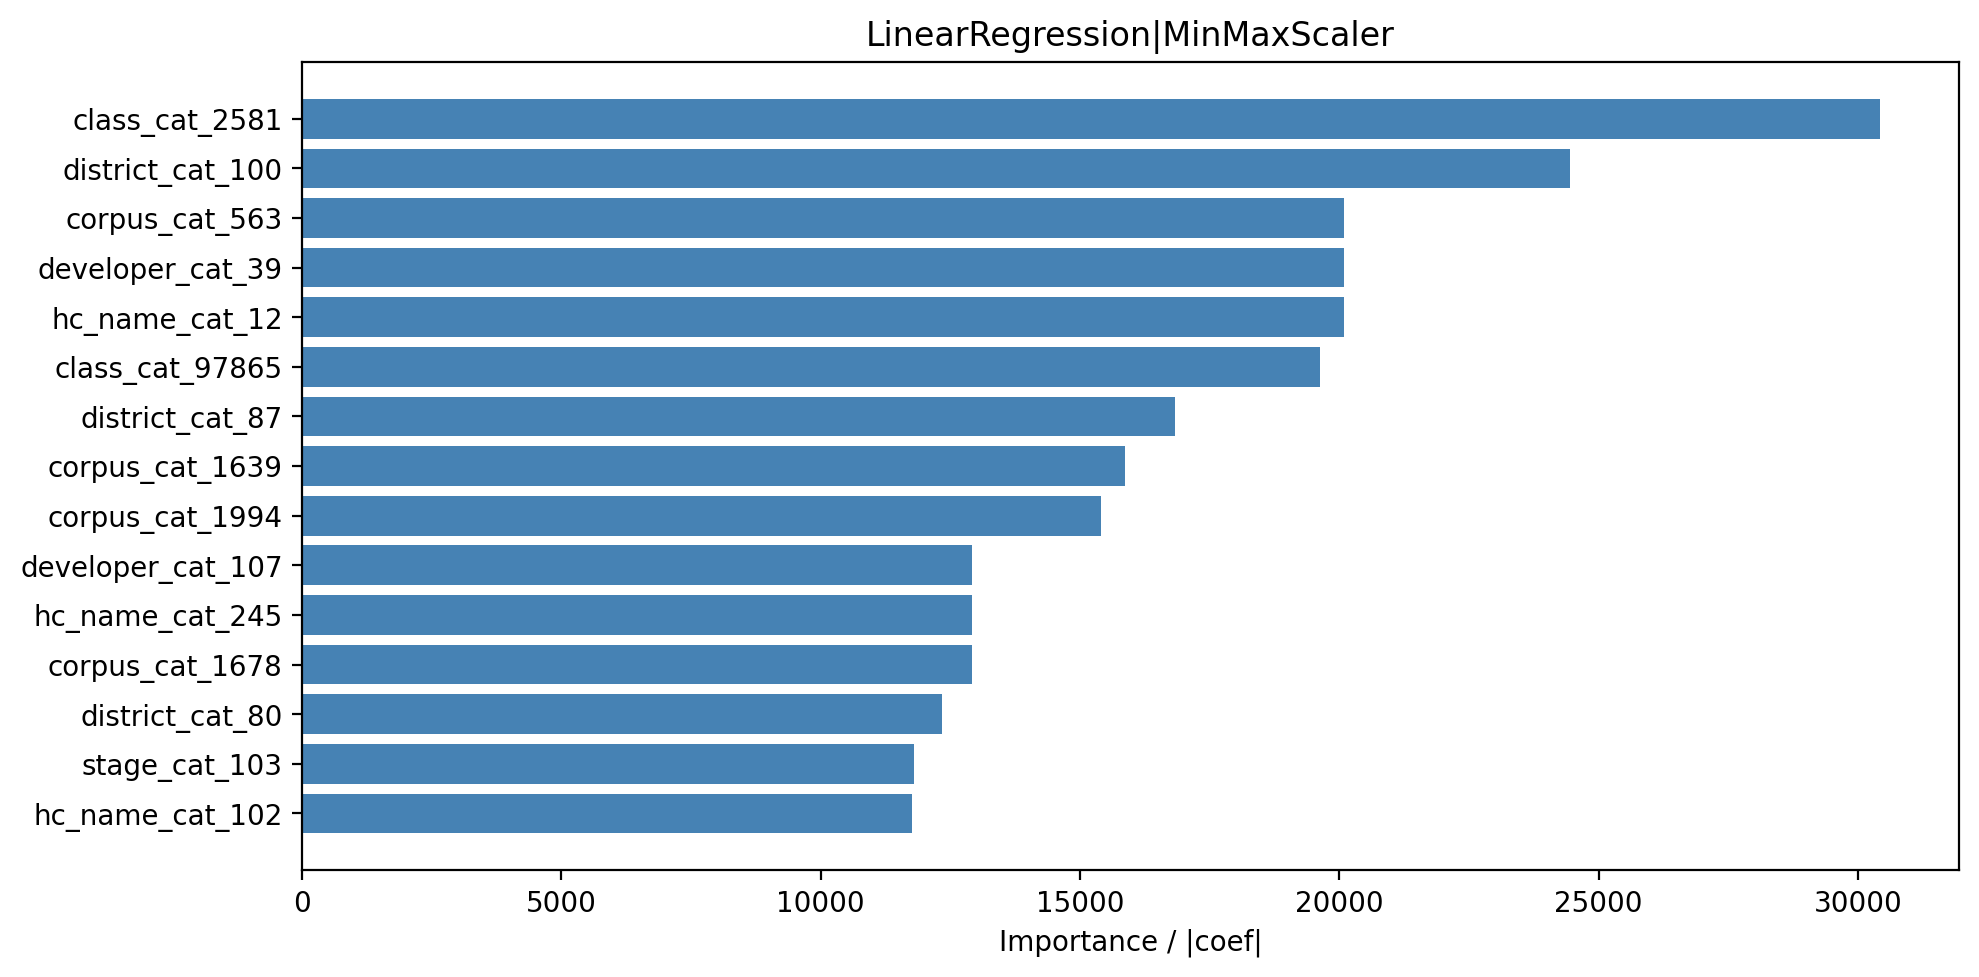

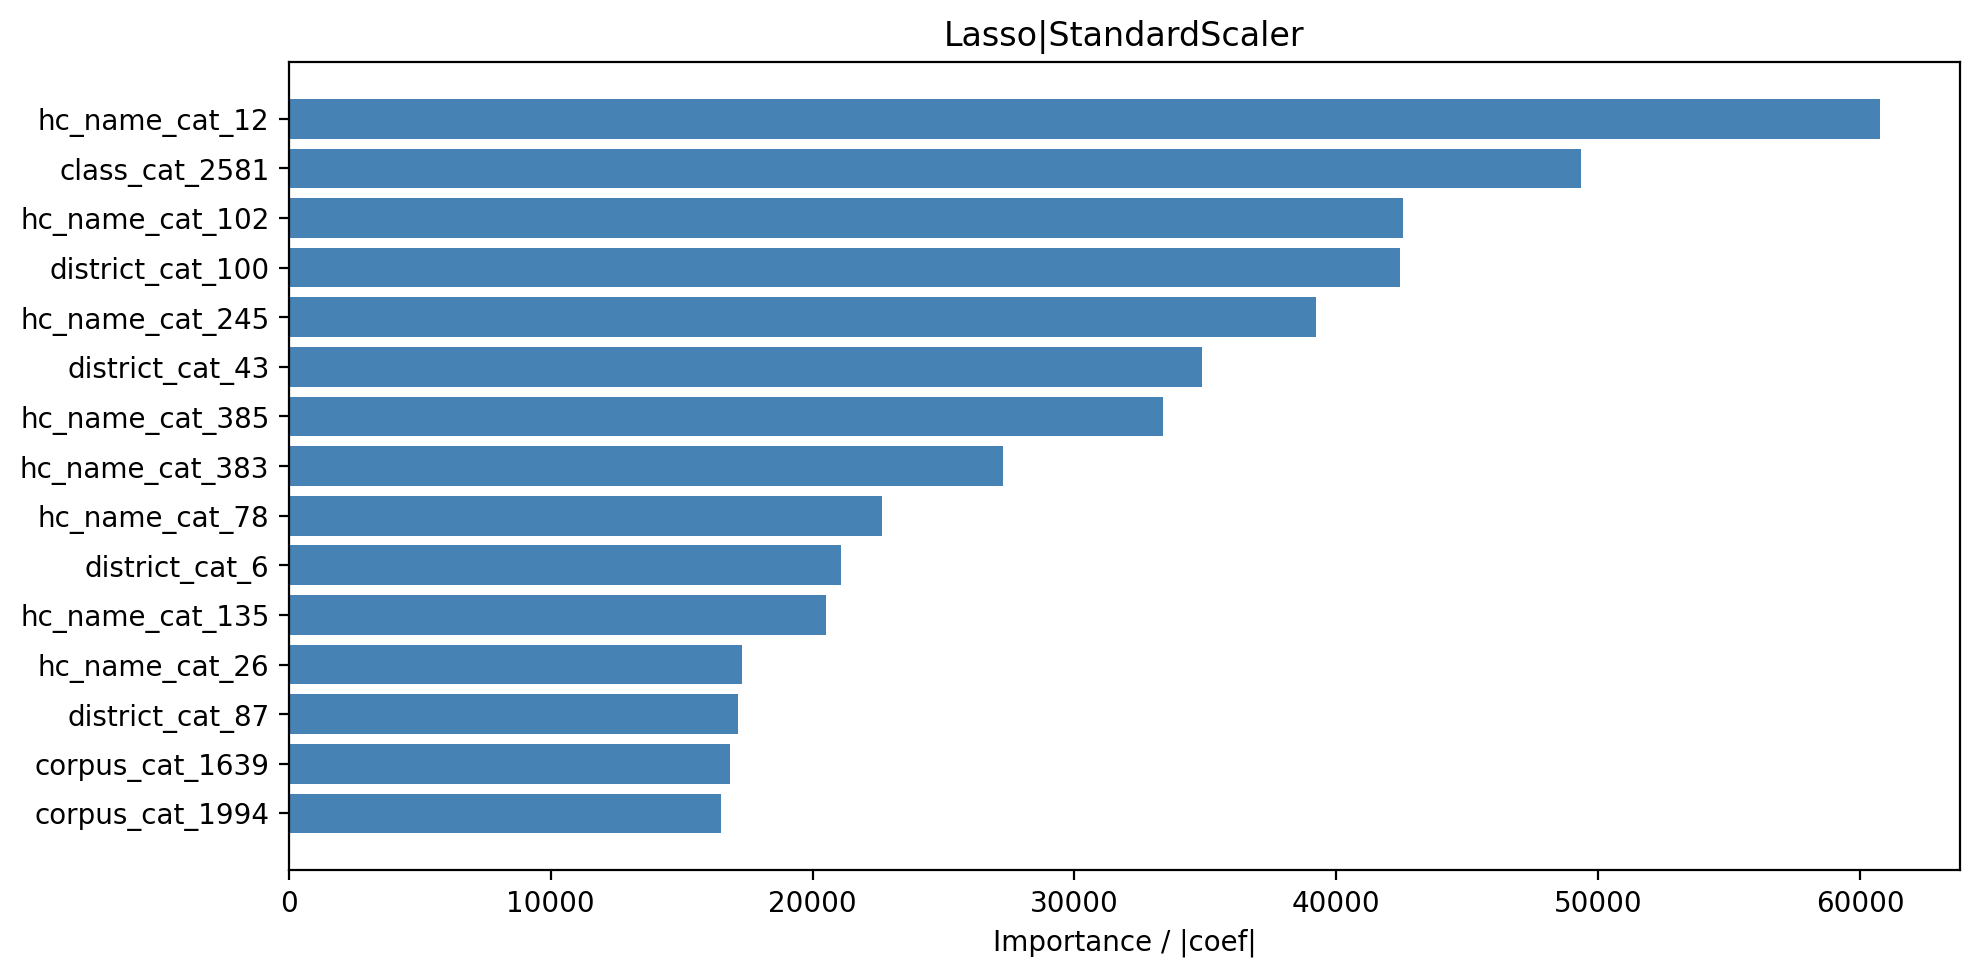

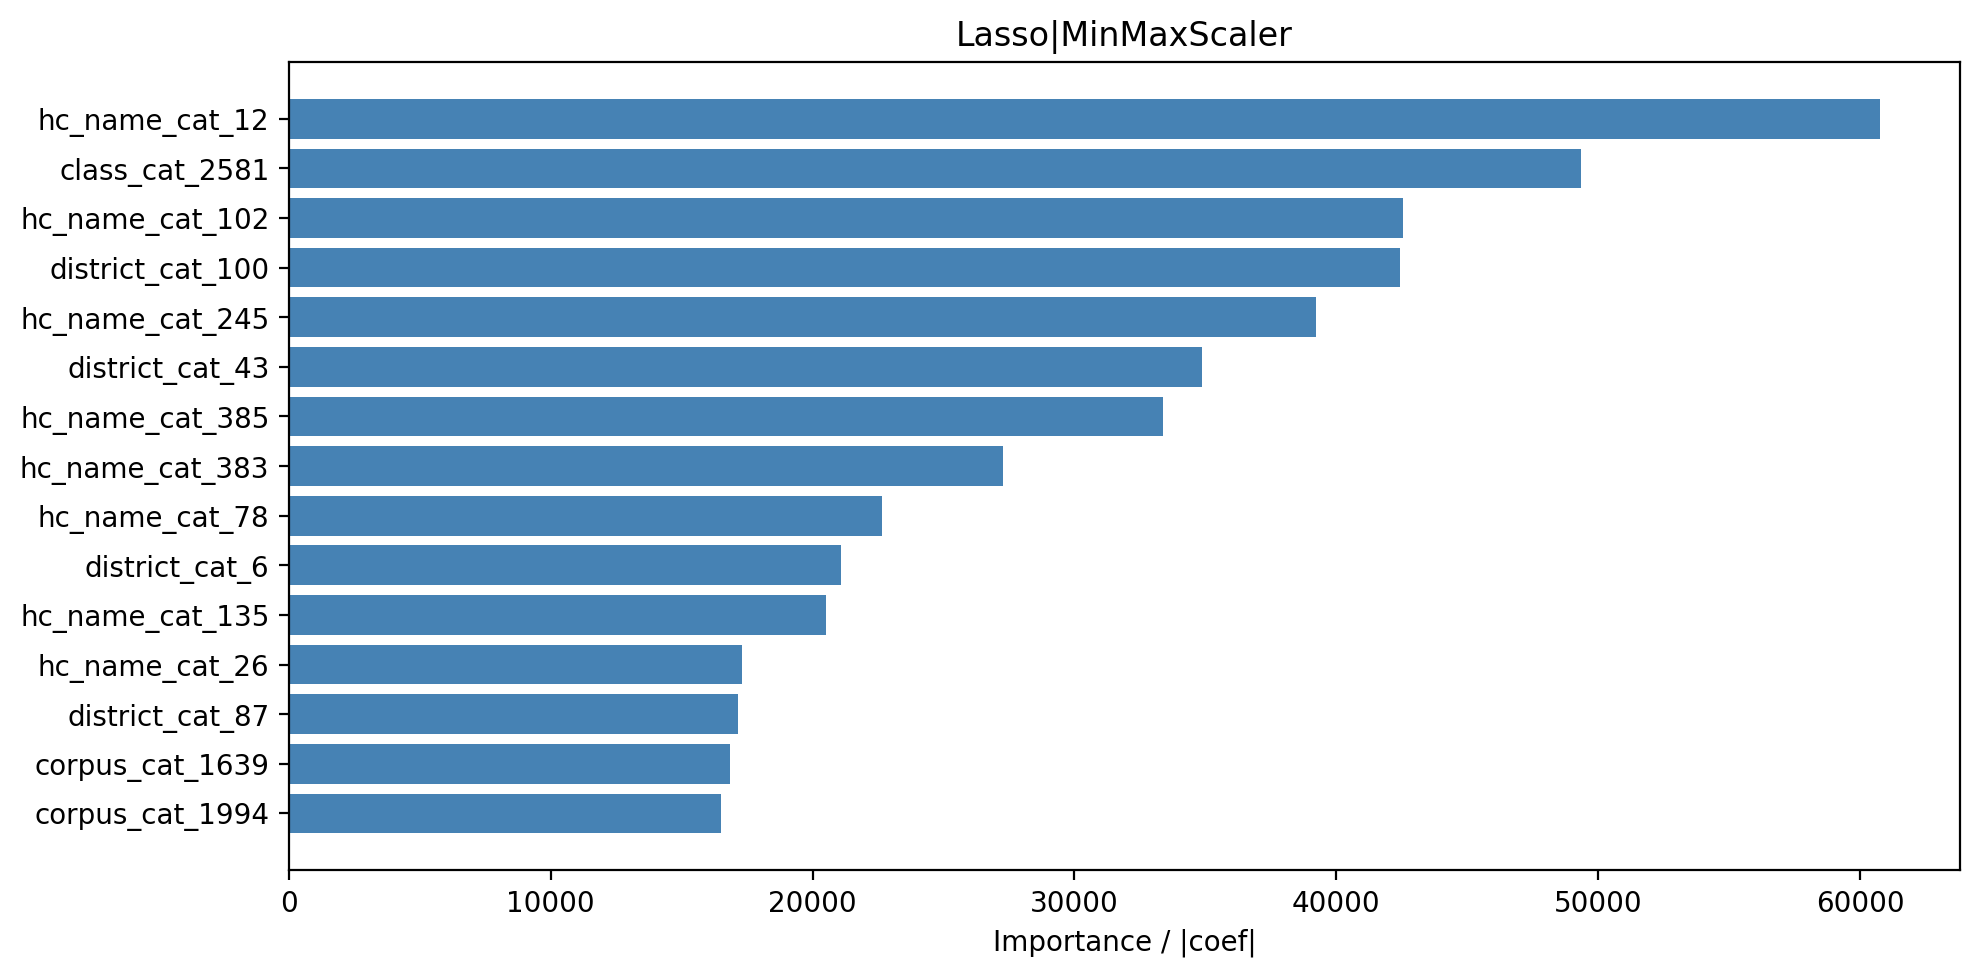

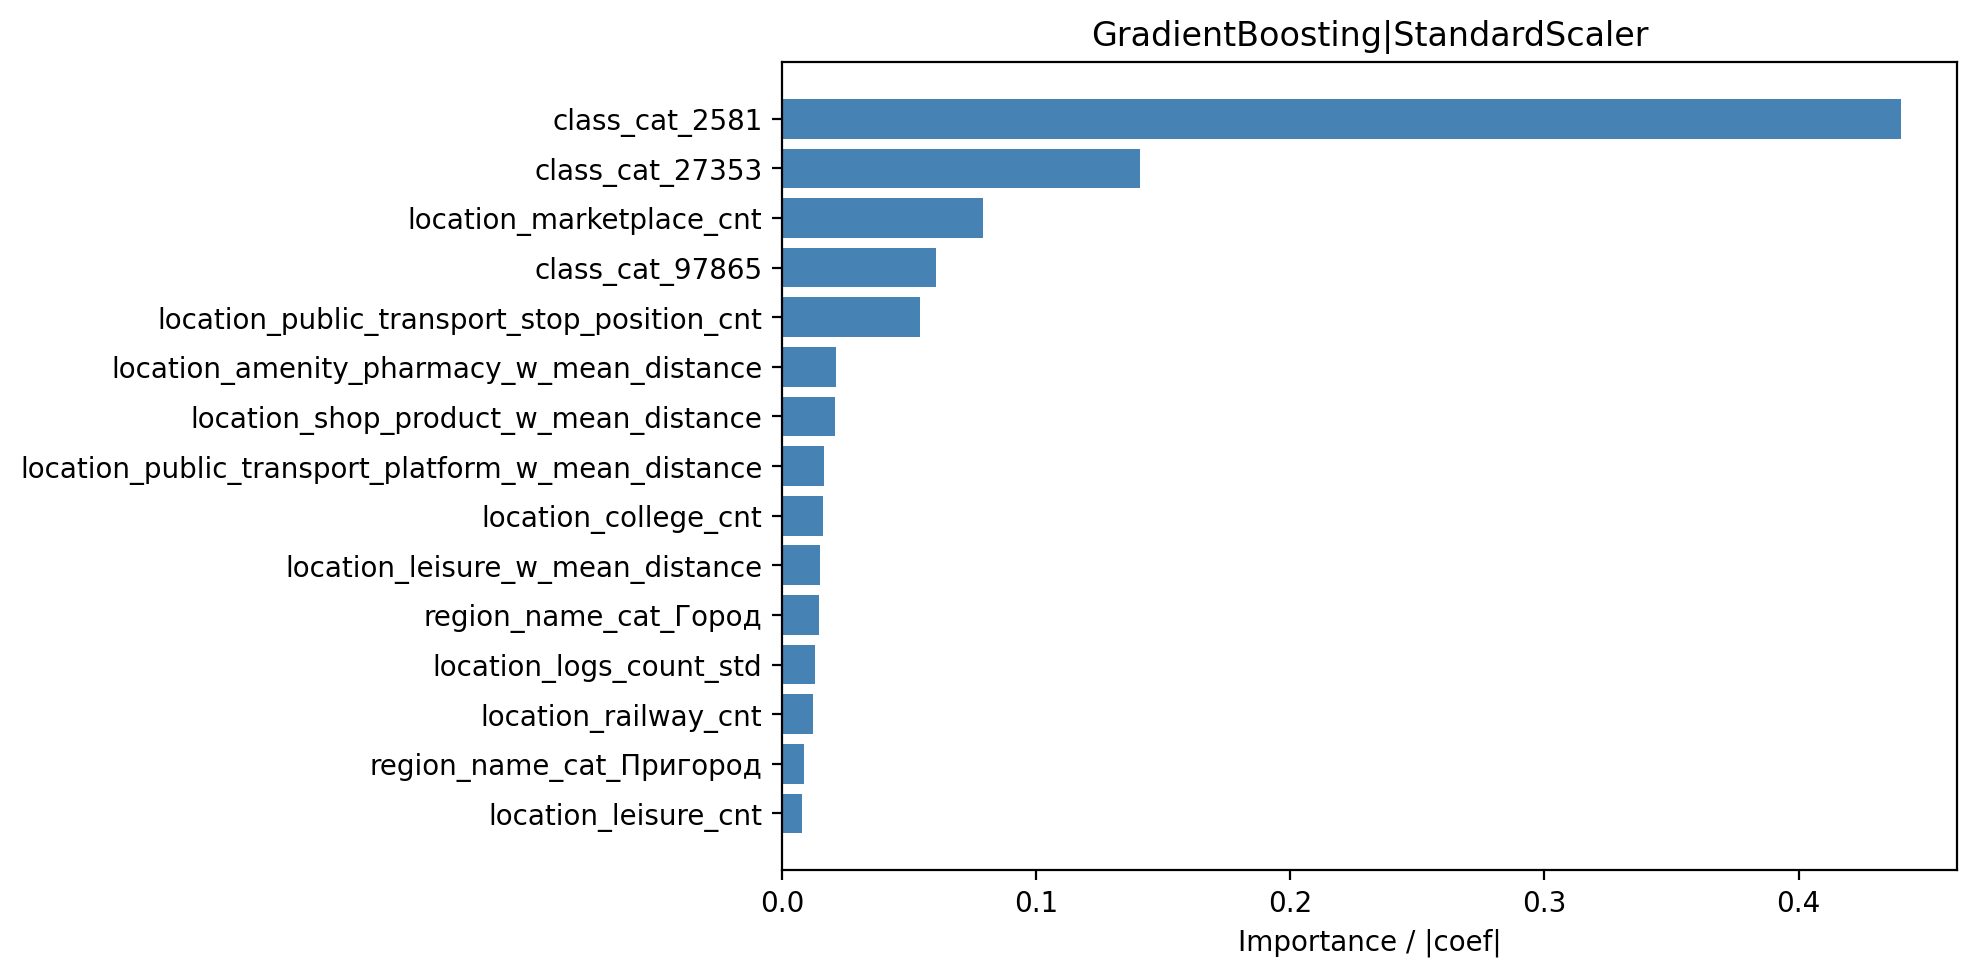

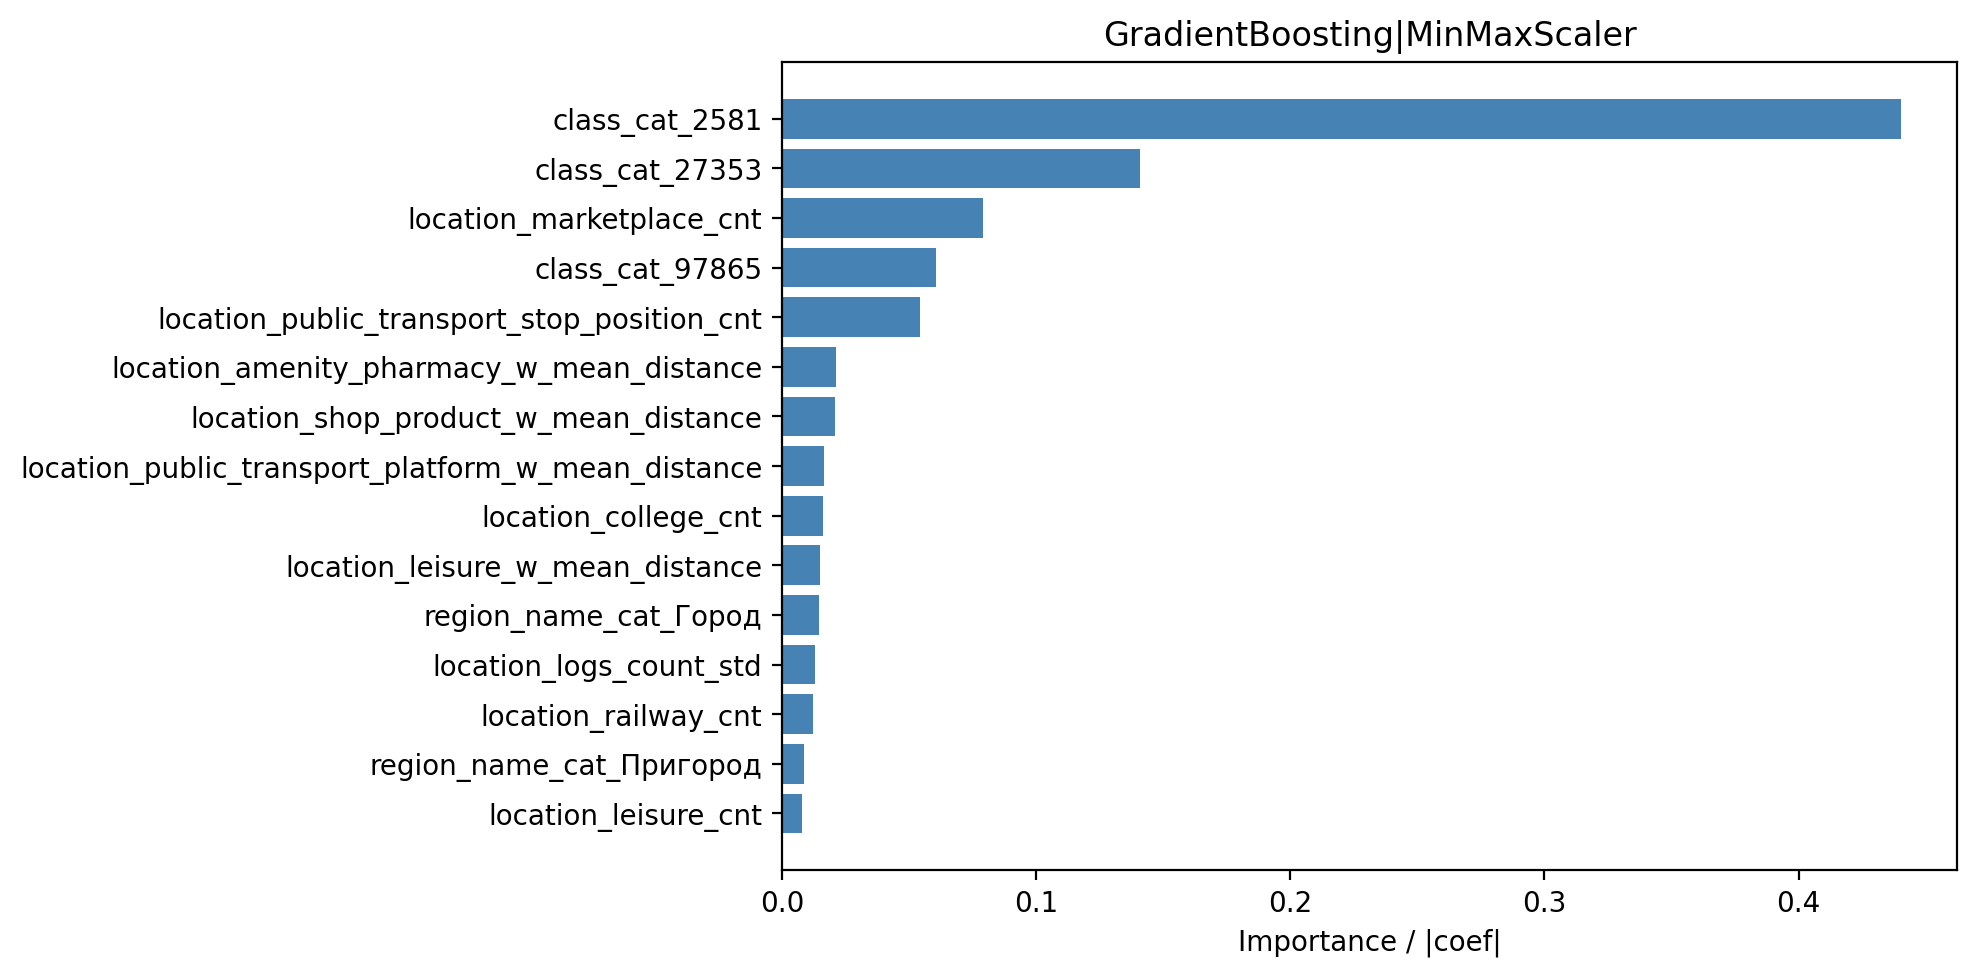

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

data = pd.read_csv("data_unreg.csv")

num_features = [
    "location_marketplace_cnt",
    "location_amenity_pharmacy_w_mean_distance",
    "location_public_transport_stop_position_cnt",
    "location_college_cnt",
    "location_railway_cnt",
    "location_logs_count_std",
    "location_leisure_cnt",
    "location_shop_product_w_mean_distance",
    "location_public_transport_platform_w_mean_distance",
    "location_leisure_w_mean_distance",
    "location_flash_mean_mean",
    "location_market_cnt",
    "location_barrier_w_mean_distance",
]
cat_features = [
    "region_name_cat", "class_cat", "district_cat",
    "hc_name_cat", "developer_cat", "corpus_cat", "stage_cat",
]

X = data[num_features + cat_features]
y = data["price_target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

def make_pre(scaler):
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="mean")), ("scaler", scaler)])
    return ColumnTransformer([("num", num_pipe, num_features), ("cat", cat_transformer, cat_features)])

models_cfg = {
    "LinearRegression": LinearRegression(),
    "Lasso":            Lasso(alpha=0.01, max_iter=10000),
    "GradientBoosting": GradientBoostingRegressor(max_depth=5, random_state=42),
}
scalers = {"StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler()}

results = {}
for mname, model in models_cfg.items():
    for sname, scaler in scalers.items():
        pipe = Pipeline([("preprocessor", make_pre(scaler)), ("regressor", model)])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        mse   = mean_squared_error(y_test, preds)
        rmse  = mse**0.5
        mape  = mean_absolute_percentage_error(y_test, preds)
        results[f"{mname}|{sname}"] = {"MSE": mse, "RMSE": rmse, "MAPE": mape, "pipe": pipe}
        print(f"{mname:20s} | {sname:15s}: RMSE={rmse:.2f}  MAPE={mape:.4f}")

# Важность признаков
def plot_importance(pipe, num_features, cat_features, title, top_n=15):
    ohe_names = (pipe.named_steps["preprocessor"]
                     .named_transformers_["cat"].named_steps["onehot"]
                     .get_feature_names_out(cat_features))
    all_names = list(num_features) + list(ohe_names)
    reg  = pipe.named_steps["regressor"]
    imps = (reg.feature_importances_ if hasattr(reg, "feature_importances_")
            else np.abs(reg.coef_))
    df = (pd.DataFrame({"feature": all_names, "importance": imps})
            .sort_values("importance", ascending=False).head(top_n))
    plt.figure(figsize=(10, 5))
    plt.barh(df["feature"], df["importance"], color="steelblue")
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Importance / |coef|")
    plt.tight_layout()
    plt.show()

for key in ["LinearRegression|StandardScaler", "LinearRegression|MinMaxScaler",
            "Lasso|StandardScaler",            "Lasso|MinMaxScaler",
            "GradientBoosting|StandardScaler", "GradientBoosting|MinMaxScaler"]:
    plot_importance(results[key]["pipe"], num_features, cat_features, title=key)


### 1. Результаты моделей с разными нормализациями

Измененный датасет:

| Модель | Normalization | MSE | RMSE | MAPE |
|--------|----------------|----------------|----------------|----------------|
| LinearRegression | StandardScaler | 4971824.73 | 2229.76 | 0.0505 |
| LinearRegression | MinMaxScaler | 4971824.73 | 2229.76 | 0.0505 |
| Lasso | StandardScaler | 4955734.56 | 2226.15 | 0.0504 |
| Lasso | MinMaxScaler | 4955557.44 | 2226.11 | 0.0504 | 0.0576 |
| GradientBoosting | StandardScaler | 6099906.11 | 2474.00 | 0.0578 |
| GradientBoosting | MinMaxScaler | 6095960.42 | 2469.00 | 0.0576 |


### 2. Выводы

1. **Влияние вида нормализации**  
   - Метрики практически не изменились при смене StandardScaler на MinMaxScaler для всех моделей.  
   - LinearRegression и Lasso слегка зависят от масштаба, но влияние минимально.  
   - Gradient Boosting стабилен к нормализации — деревья работают одинаково на обоих scaler.

2. **Важность признаков**  
   - Диаграммы важности для каждой модели совпали для StandardScaler и MinMaxScaler.  
   - Это показывает, что **относительная значимость признаков не зависит от способа нормализации**, даже для линейных моделей (по крайней мере для этого датасета).  
   - Для Gradient Boosting нормализация не влияет ни на метрики, ни на важность признаков.

3. **Вывод для практического использования**  
   - Для линейных моделей нормализация нужна в основном для интерпретации коэффициентов.  
   - Для деревьев и Gradient Boosting нормализация не обязательна, что упрощает построение модели и анализ важности признаков.